In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [23]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("building_seg_data")


In [ ]:
# Load secrets from .env
from dotenv import load_dotenv
import os

load_dotenv()

# Get Roboflow key
building_seg_data = os.getenv('building_seg_data')

In [ ]:
# !pip install roboflow

from roboflow import Roboflow
# rf = Roboflow(api_key = secret_value_0)
rf = Roboflow(api_key = building_seg_data)
project = rf.workspace("roboflow-universe-projects").project("buildings-instance-segmentation")
version = project.version(1)
dataset = version.download("coco-segmentation")
                

loading Roboflow workspace...
loading Roboflow project...


In [25]:
import json
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Specify where Roboflow downloaded the dataset
dataset_path = "/kaggle/working/Buildings-Instance-Segmentation-1" 

# Load annotations
with open(f'{dataset_path}/train/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

# Create a class to easily access the dataset
class RoboflowCOCODataset:
    def __init__(self, coco_data, image_dir):
        self.coco_data = coco_data
        self.image_dir = image_dir
        self.images = coco_data['images']
        self.annotations = coco_data['annotations']
        
        # Create annotation lookup by image_id
        self.anns_by_image = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.anns_by_image:
                self.anns_by_image[img_id] = []
            self.anns_by_image[img_id].append(ann)
    
    def __getitem__(self, idx):
        # Get image info
        image_info = self.images[idx]
        image_path = os.path.join(self.image_dir, image_info['file_name'])
        
        # Load image
        image = Image.open(image_path)
        
        # Get annotations
        image_id = image_info['id']
        annotations = self.anns_by_image.get(image_id, [])
        
        # Extract bounding boxes
        bboxes = [ann['bbox'] for ann in annotations]
        
        # Extract segmentation masks (if needed)
        segmentations = [ann['segmentation'] for ann in annotations]
        
        return {
            'image': image,
            'bboxes': bboxes,
            'segmentations': segmentations,
            'image_id': image_id,
            'annotations': annotations
        }
    
    def __len__(self):
        return len(self.images)

# Create dataset instance
train_dataset = RoboflowCOCODataset(coco_data, f'{dataset_path}/train')

# Get first example
example = train_dataset[0]
image = example['image']
bboxes = example['bboxes']
segmentations = example['segmentations']

print(f" Dataset loaded!")
print(f"   Image size: {image.size}")
print(f"   Number of buildings: {len(bboxes)}")
print(f"   Sample bbox: {bboxes[0] if bboxes else 'None'}")

 Dataset loaded!
   Image size: (500, 500)
   Number of buildings: 15
   Sample bbox: [128, 357, 56.6, 54.27]


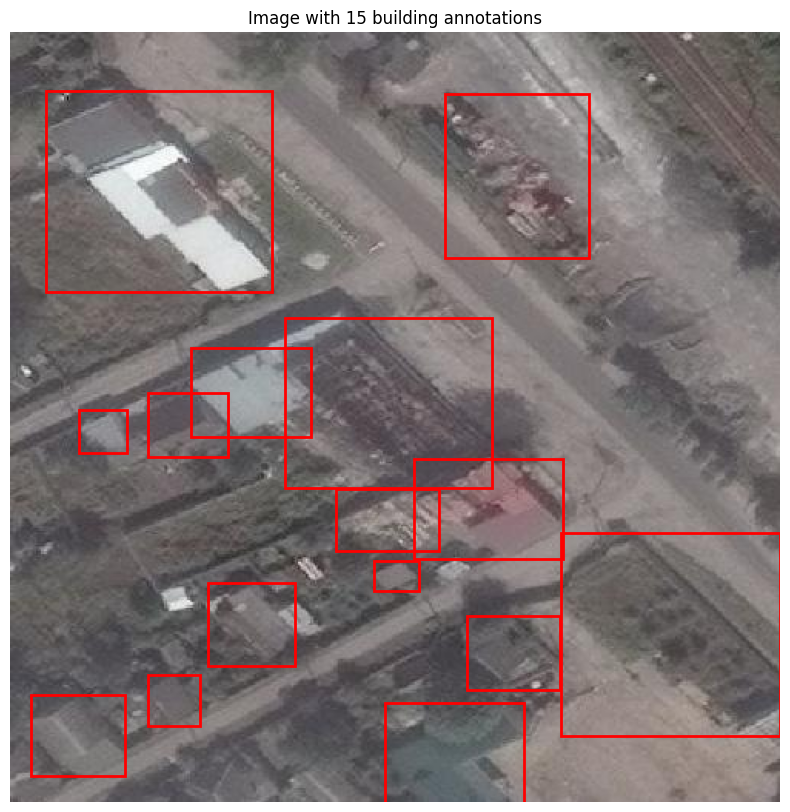

In [26]:
# Display image with bounding boxes
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(image)

for bbox in bboxes:
    x_min, y_min, width, height = bbox
    rect = patches.Rectangle((x_min, y_min), width, height, 
                            linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

ax.set_title(f'Image with {len(bboxes)} building annotations')
ax.axis('off')
plt.show()

Mask shape: (500, 500)
Unique values: [0 1]


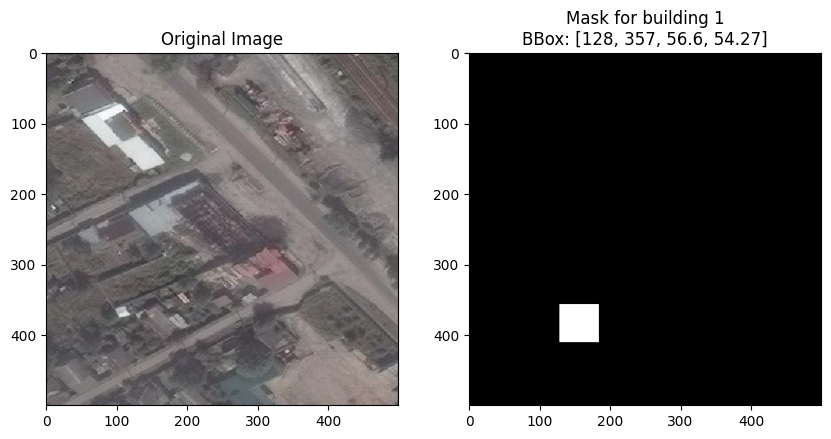

In [27]:
def make_mask(bbox, image):
    """Create binary mask from bounding box"""
    # Get image dimensions
    if hasattr(image, 'size'):
        width, height = image.size
    else:
        height, width = image.shape[:2]
    
    # Extract bbox coordinates
    x_min, y_min, bbox_width, bbox_height = bbox
    x_min, y_min = int(x_min), int(y_min)
    x_max = int(x_min + bbox_width)
    y_max = int(y_min + bbox_height)
    
    # Create mask (numpy uses height, width format)
    mask = np.zeros((height, width), dtype=np.uint8)
    mask[y_min:y_max, x_min:x_max] = 1
    
    return mask

# Test the mask function with first building
if bboxes:
    test_bbox = bboxes[0]
    test_mask = make_mask(test_bbox, image)
    print(f"Mask shape: {test_mask.shape}")
    print(f"Unique values: {np.unique(test_mask)}")
    
    # Display mask
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[1].imshow(test_mask, cmap='gray')
    axes[1].set_title(f'Mask for building 1\nBBox: {test_bbox}')
    plt.show()

In [28]:
import sys
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Download SAM checkpoint if not exists
import os
if not os.path.exists("sam_vit_h_4b8939.pth"):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# Initialize SAM
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)
print(" SAM model loaded!")

Using device: cuda
 SAM model loaded!


Generated 98 masks from SAM


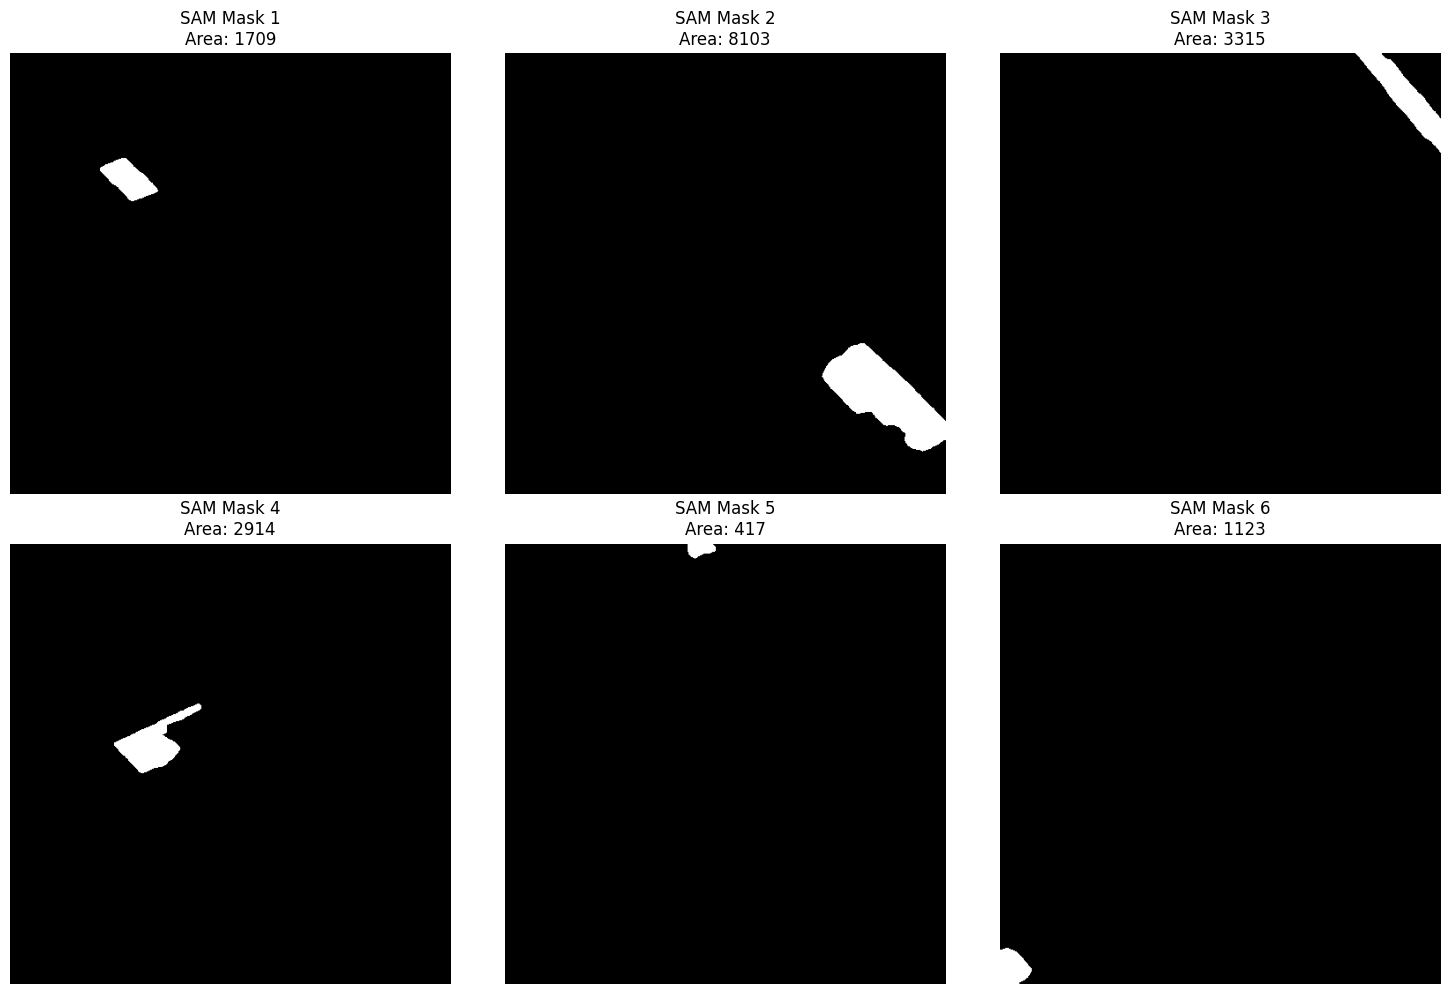

In [29]:
import numpy as np

# Convert PIL image to numpy array for SAM
image_np = np.array(image)

# Generate masks
sam_masks = mask_generator.generate(image_np)
print(f"Generated {len(sam_masks)} masks from SAM")

# Display some SAM masks
if len(sam_masks) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(sam_masks):
            mask = sam_masks[i]['segmentation']
            ax.imshow(mask, cmap='gray')
            ax.set_title(f'SAM Mask {i+1}\nArea: {sam_masks[i]["area"]}')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

IoU: 0.434


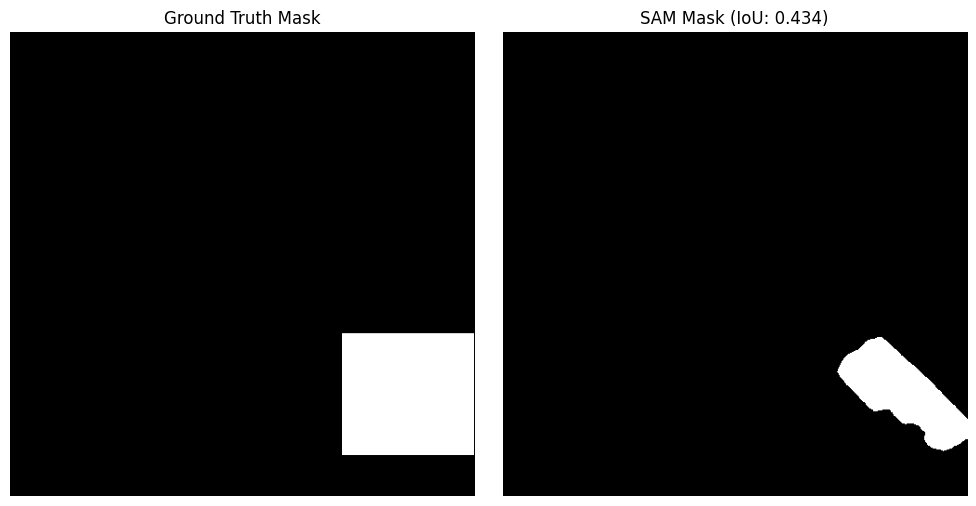

IoU: 0.524


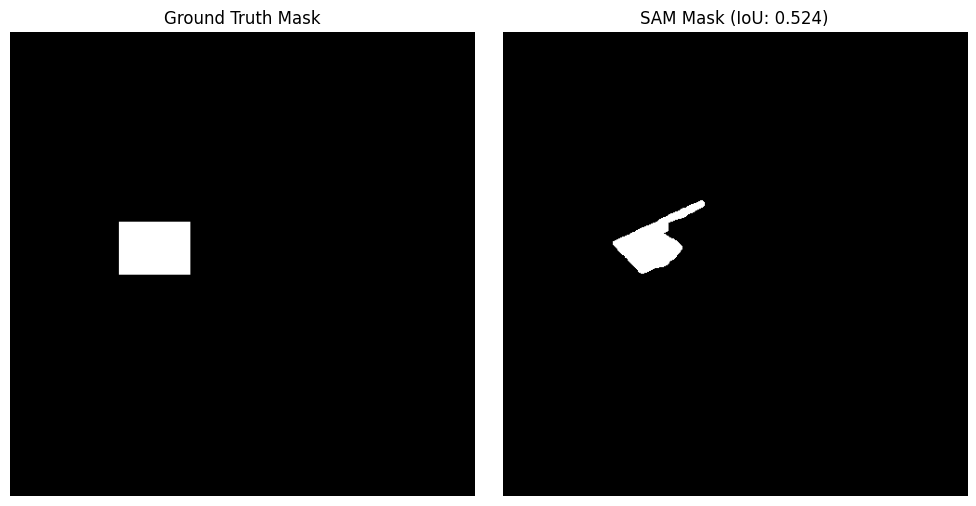

IoU: 0.606


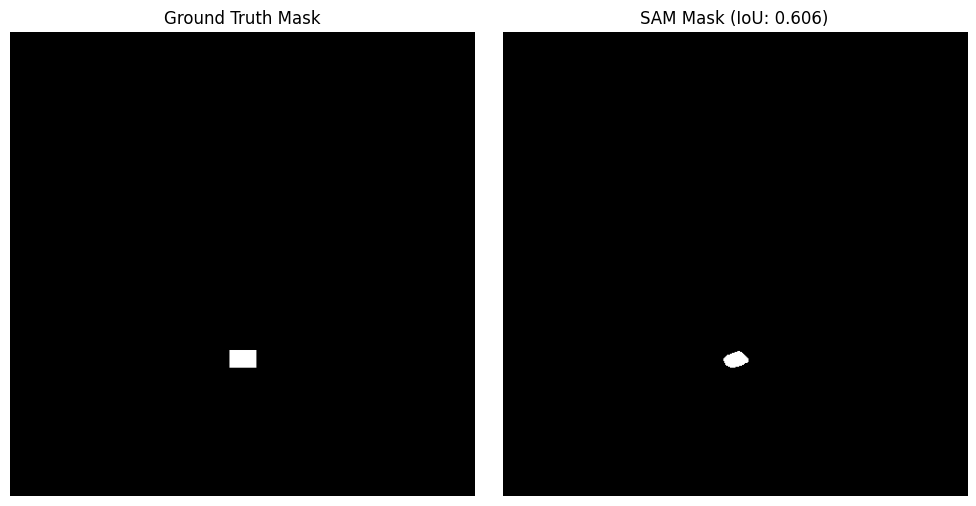

IoU: 0.515


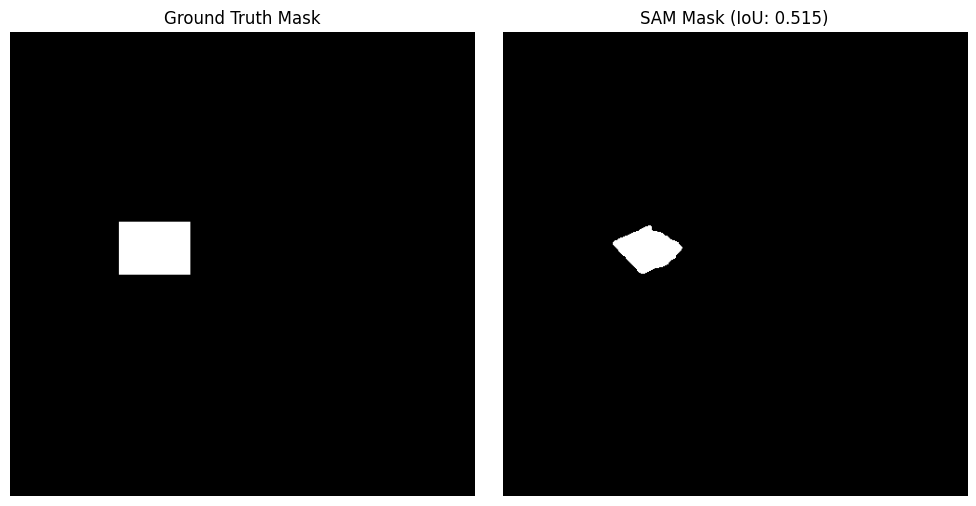

IoU: 0.355


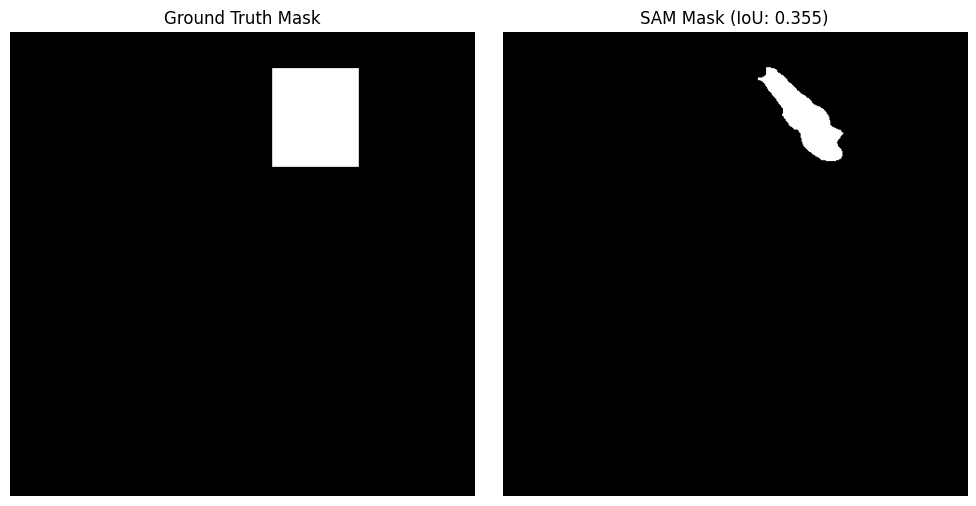

IoU: 0.589


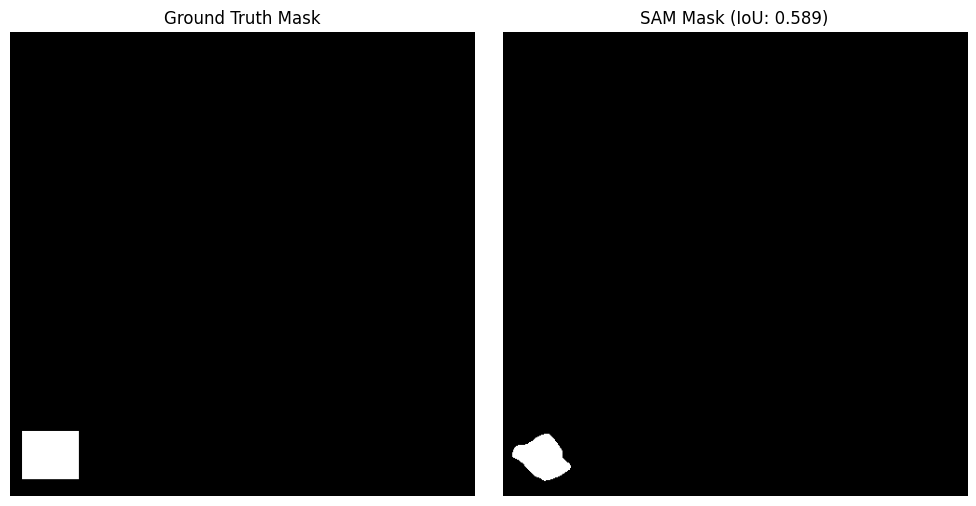

IoU: 0.618


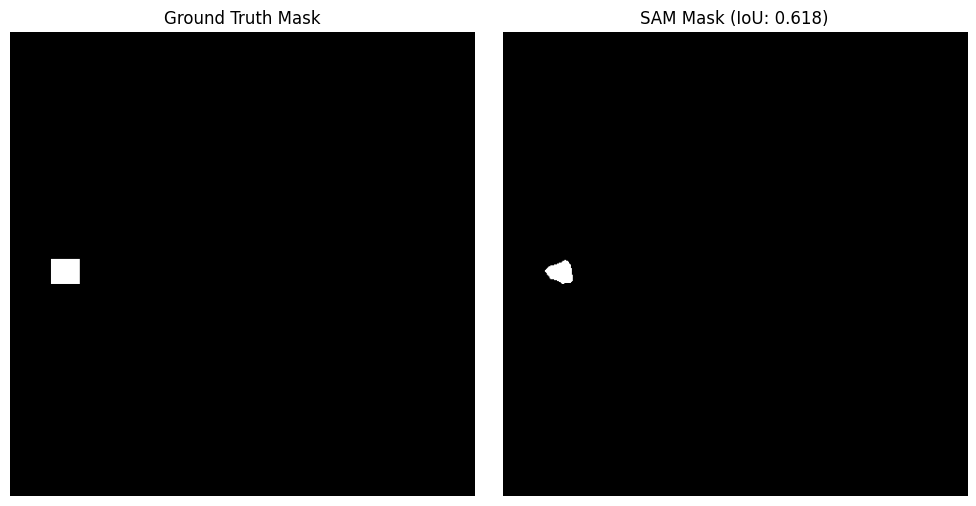

IoU: 0.498


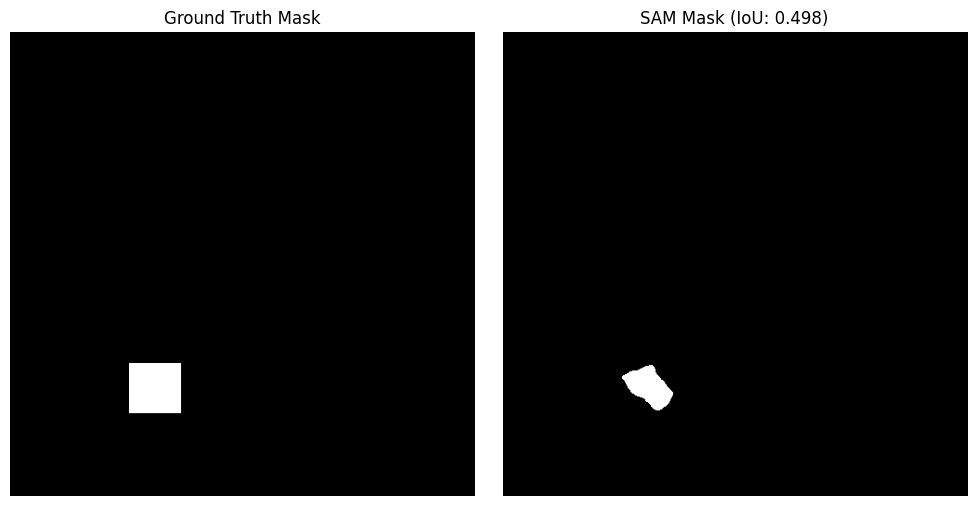

IoU: 0.606


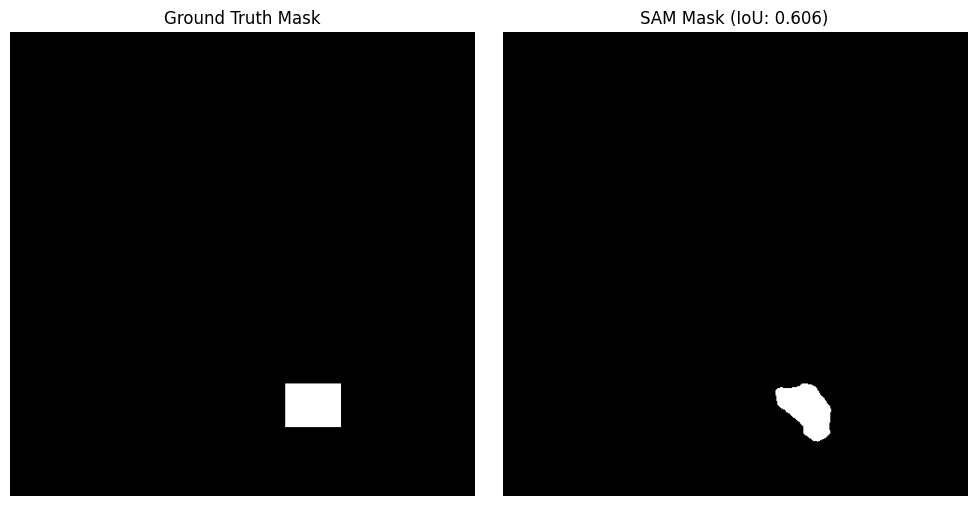

IoU: 0.363


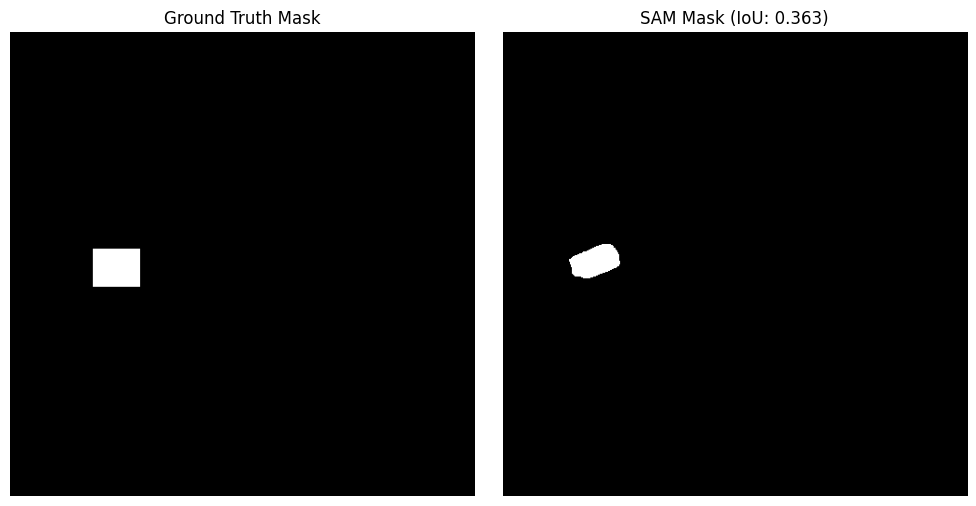

IoU: 0.523


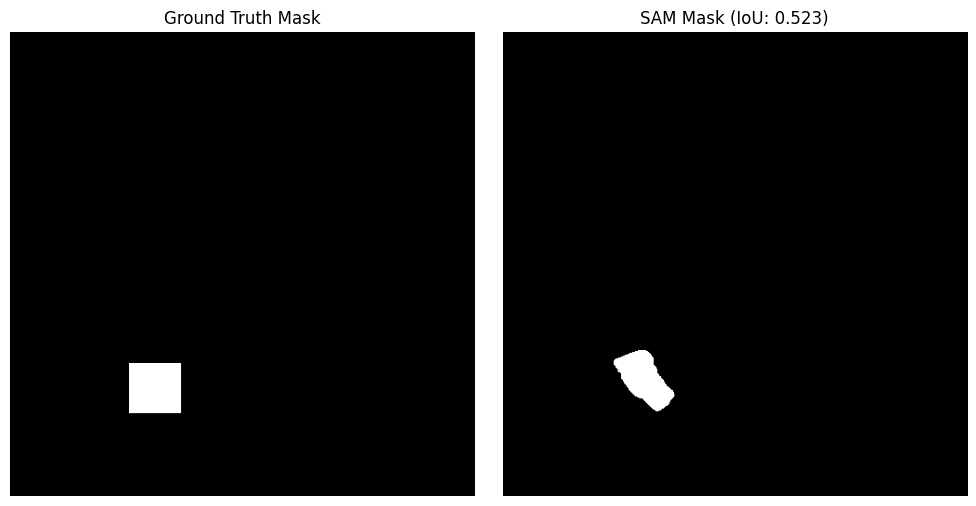

IoU: 0.537


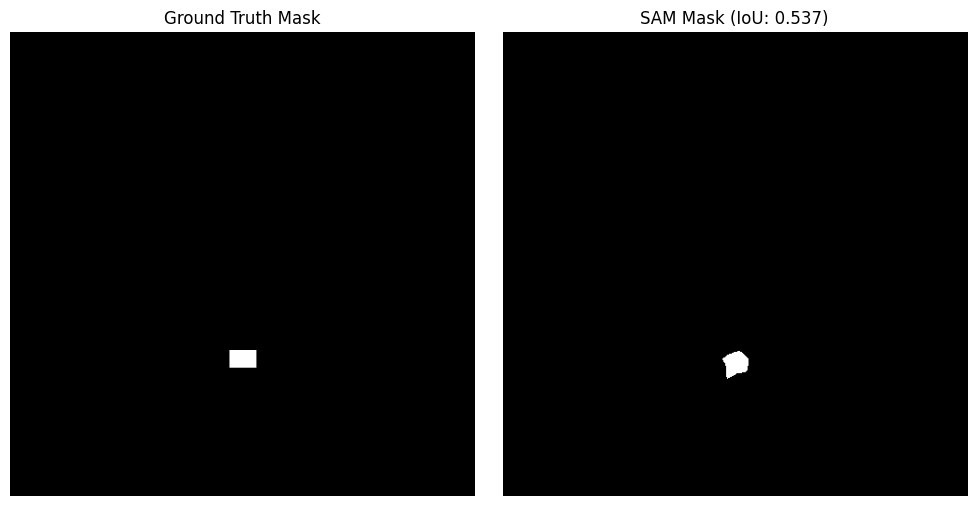

IoU: 0.553


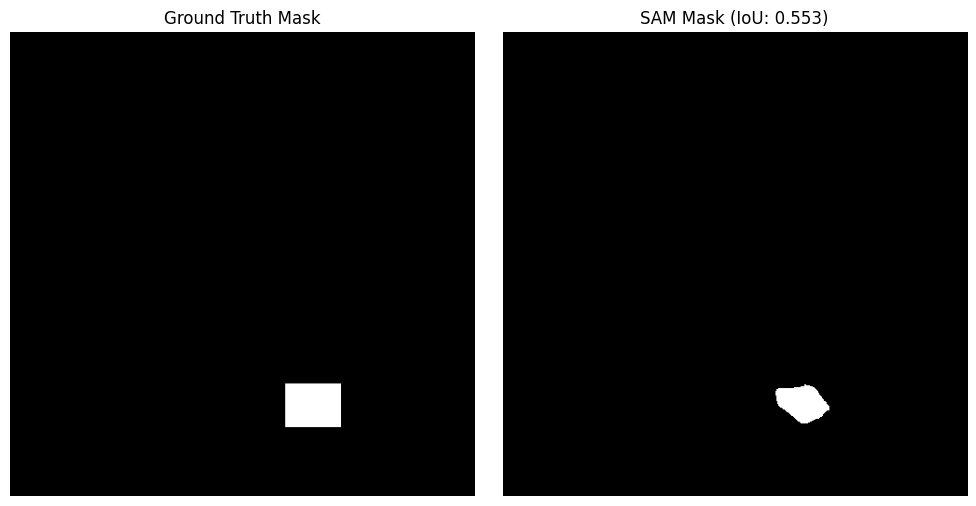


Found 13 matches with IoU > 0.3
Average IoU: 0.517


In [30]:
from scipy.spatial import distance

# Calculate IoU between SAM masks and ground truth bounding boxes
ious = []

for sam_mask_data in sam_masks:
    sam_seg = sam_mask_data['segmentation'].astype(int)
    
    for gt_bbox in bboxes:
        # Create ground truth mask from bounding box
        gt_mask = make_mask(gt_bbox, image)
        
        # Calculate IoU
        intersection = np.logical_and(sam_seg, gt_mask).sum()
        union = np.logical_or(sam_seg, gt_mask).sum()
        
        if union > 0:
            iou = intersection / union
            if iou > 0.3:  # Only show matches above 0.3 IoU
                ious.append(iou)
                print(f"IoU: {iou:.3f}")
                
                # Visualize the match
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(gt_mask, cmap='gray')
                axes[0].set_title('Ground Truth Mask')
                axes[0].axis('off')
                
                axes[1].imshow(sam_seg, cmap='gray')
                axes[1].set_title(f'SAM Mask (IoU: {iou:.3f})')
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()

print(f"\nFound {len(ious)} matches with IoU > 0.3")
if ious:
    print(f"Average IoU: {np.mean(ious):.3f}")

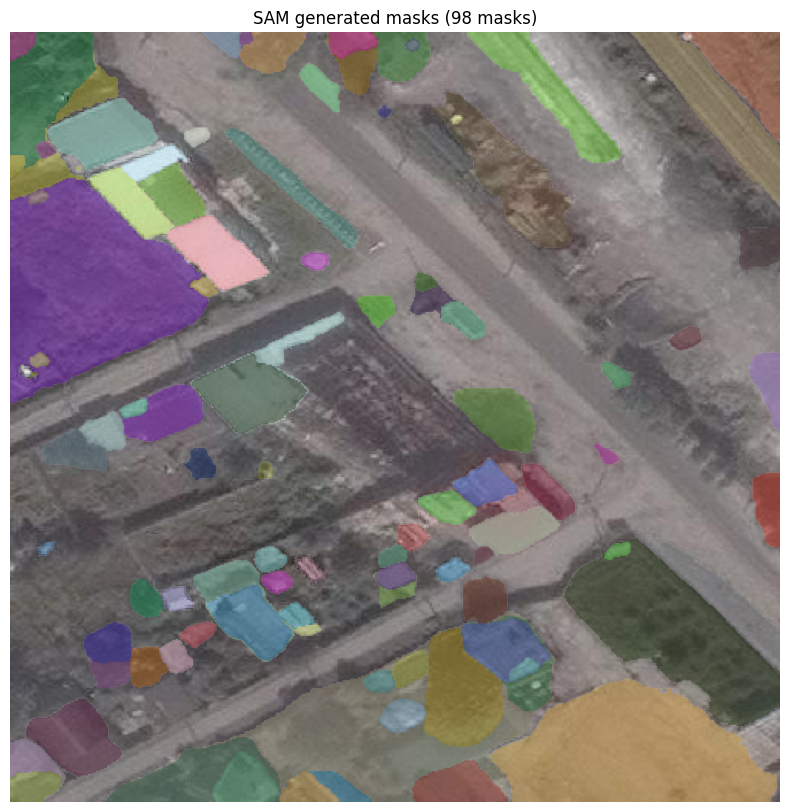

In [31]:
def show_anns(anns):
    """Display SAM masks with random colors"""
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], 
                   sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

plt.figure(figsize=(10,10))
plt.imshow(image)
show_anns(sam_masks)
plt.title(f'SAM generated masks ({len(sam_masks)} masks)')
plt.axis('off')
plt.show()

In [32]:
# Install segmentation models library
# !pip install segmentation-models-pytorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchvision import transforms
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

In [33]:
# Cell 9: Create PyTorch Dataset (Returns ONLY Tensors)
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import json
import os

class BuildingSegmentationDataset(Dataset):
    def __init__(self, coco_data, image_dir, mask_size=(512, 512)):
        self.coco_data = coco_data
        self.image_dir = image_dir
        self.mask_size = mask_size
        
        # Build annotation lookup
        self.images = coco_data['images']
        self.annotations = coco_data['annotations']
        
        self.anns_by_image = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.anns_by_image:
                self.anns_by_image[img_id] = []
            self.anns_by_image[img_id].append(ann)
        
        # Filter images with annotations
        self.valid_images = [img for img in self.images 
                            if img['id'] in self.anns_by_image]
        
        print(f"Dataset ready: {len(self.valid_images)} images with annotations")
    
    def __len__(self):
        return len(self.valid_images)
    
    def combine_masks(self, bboxes, image):
        """Combine multiple bounding box masks"""
        if hasattr(image, 'size'):
            width, height = image.size
        else:
            height, width = image.shape[:2]
        
        combined_mask = np.zeros((height, width), dtype=np.uint8)
        
        for bbox in bboxes:
            mask = make_mask(bbox, image)  # Your existing function
            combined_mask = np.logical_or(combined_mask, mask).astype(np.uint8)
        
        return combined_mask
    
    def __getitem__(self, idx):
        # Get image info
        img_info = self.valid_images[idx]
        image_path = os.path.join(self.image_dir, img_info['file_name'])
        
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        # Get annotations
        annotations = self.anns_by_image[img_info['id']]
        bboxes = [ann['bbox'] for ann in annotations]
        
        # Create mask
        mask = self.combine_masks(bboxes, image)
        
        # Resize
        image_resized = image.resize(self.mask_size, Image.Resampling.BILINEAR)
        mask_img = Image.fromarray((mask * 255).astype(np.uint8))
        mask_resized = mask_img.resize(self.mask_size, Image.Resampling.NEAREST)
        mask_array = np.array(mask_resized) / 255.0
        
        # Convert to tensors
        image_np = np.array(image_resized) / 255.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0).float()
        
        # Return only tensors and numbers
        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'num_buildings': len(bboxes)
        }

# Load COCO annotations
with open(f'{dataset_path}/train/_annotations.coco.json', 'r') as f:
    train_coco = json.load(f)
with open(f'{dataset_path}/valid/_annotations.coco.json', 'r') as f:
    val_coco = json.load(f)
with open(f'{dataset_path}/test/_annotations.coco.json', 'r') as f:
    test_coco = json.load(f)

print(f"Train: {len(train_coco['images'])} images")
print(f"Val: {len(val_coco['images'])} images")
print(f"Test: {len(test_coco['images'])} images")

# Create datasets
train_dataset = BuildingSegmentationDataset(train_coco, f'{dataset_path}/train', mask_size=(512, 512))
val_dataset = BuildingSegmentationDataset(val_coco, f'{dataset_path}/valid', mask_size=(512, 512))
test_dataset = BuildingSegmentationDataset(test_coco, f'{dataset_path}/test', mask_size=(512, 512))

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"\n✅ Dataloaders created successfully!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

Train: 6764 images
Val: 1934 images
Test: 967 images
Dataset ready: 5932 images with annotations
Dataset ready: 1731 images with annotations
Dataset ready: 847 images with annotations

✅ Dataloaders created successfully!
   Train batches: 742
   Val batches: 217
   Test batches: 106


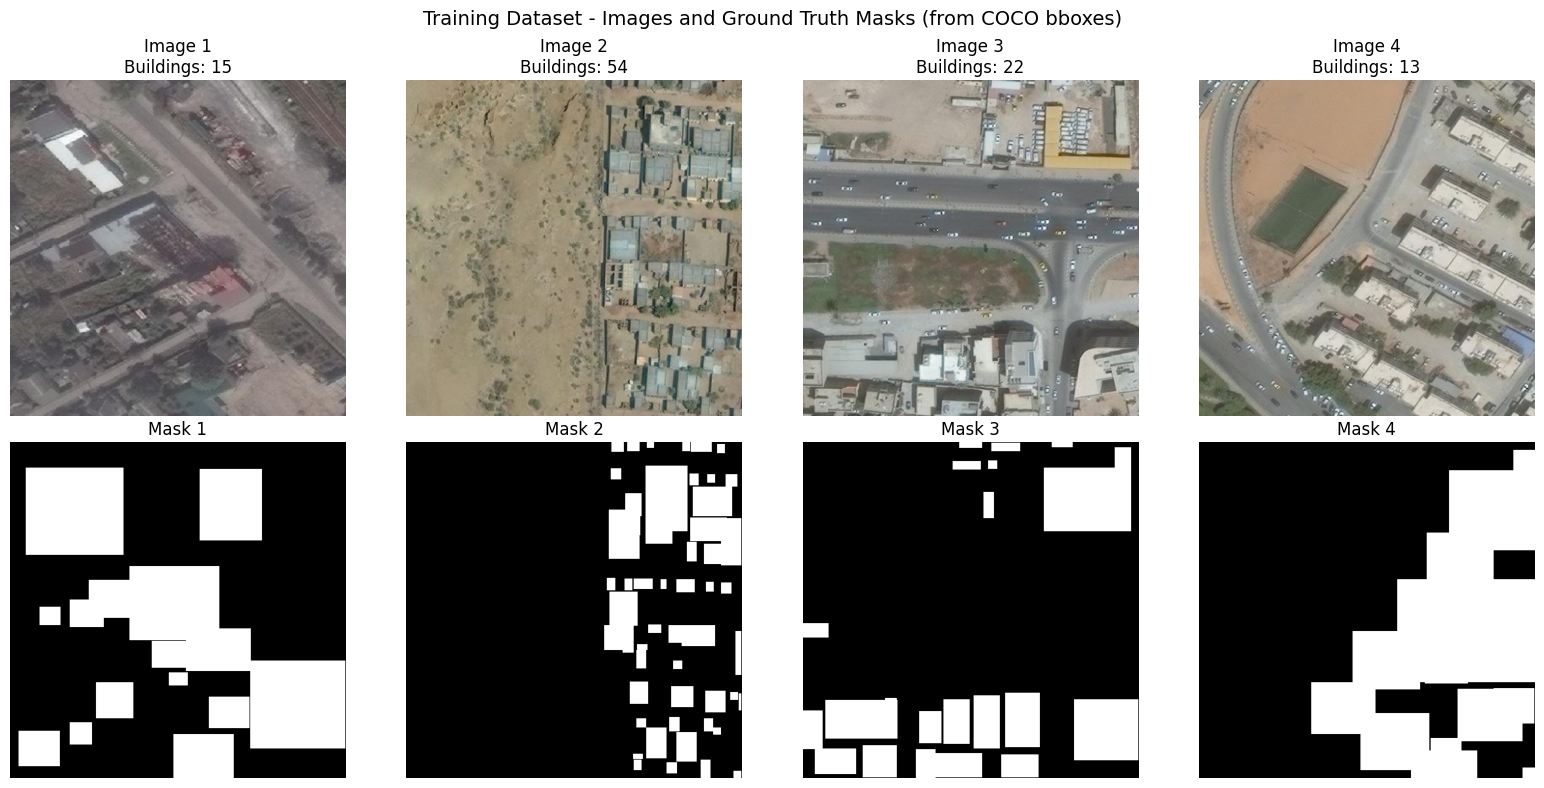

In [34]:
# Visualize some samples - using your existing display style
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    sample = train_dataset[i]
    image = sample['image'].permute(1, 2, 0).numpy()
    mask = sample['mask'].squeeze().numpy()
    
    axes[0, i].imshow(image)
    axes[0, i].set_title(f'Image {i+1}\nBuildings: {sample["num_buildings"]}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f'Mask {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Training Dataset - Images and Ground Truth Masks (from COCO bboxes)', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# UNet model
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation='sigmoid'
)

model = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model parameters: 24,436,369


In [36]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
    
    def forward(self, pred, target):
        return self.bce_weight * self.bce(pred, target) + self.dice_weight * self.dice(pred, target)

def calculate_iou(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def calculate_dice(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    return (2. * intersection + 1e-6) / (pred_binary.sum() + target.sum() + 1e-6)

# Initialize
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

In [ ]:
num_epochs = 15
best_val_loss = float('inf')
train_losses, val_losses, val_ious, val_dices = [], [], [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            
            for i in range(images.size(0)):
                val_iou += calculate_iou(outputs[i], masks[i])
                val_dice += calculate_dice(outputs[i], masks[i])
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_dataset)
    avg_val_dice = val_dice / len(val_dataset)
    
    val_losses.append(avg_val_loss)
    val_ious.append(avg_val_iou)
    val_dices.append(avg_val_dice)
    
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_unet_model.pth')
        print(f" Saved best model - IoU: {avg_val_iou:.4f}, Dice: {avg_val_dice:.4f}")
    
    print(f"Epoch {epoch+1}: Loss={avg_train_loss:.4f}/{avg_val_loss:.4f}, IoU={avg_val_iou:.4f}, Dice={avg_val_dice:.4f}")

print(" Training complete!")

Epoch 1/15 [Val]: 100%|██████████| 217/217 [00:32<00:00,  6.62it/s]


✅ Saved best model - IoU: 0.6834, Dice: 0.7947
Epoch 1: Loss=0.2999/0.2073, IoU=0.6834, Dice=0.7947


Epoch 2/15 [Val]:  19%|█▉        | 41/217 [00:06<00:26,  6.69it/s]

In [ ]:
# Plot training curves (using the already split datasets)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU curve
axes[1].plot(val_ious, color='green', linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('IoU Score', fontsize=12)
axes[1].set_title('Validation IoU', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

# Dice curve
axes[2].plot(val_dices, color='orange', linewidth=2, marker='s', markersize=4)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Dice Score', fontsize=12)
axes[2].set_title('Validation Dice Score', fontsize=14)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print best results
best_epoch = val_ious.index(max(val_ious))
print(f"\n Best Results:")
print(f"   Best IoU: {max(val_ious):.4f} (Epoch {best_epoch + 1})")
print(f"   Best Dice: {max(val_dices):.4f} (Epoch {val_dices.index(max(val_dices)) + 1})")
print(f"   Best Val Loss: {min(val_losses):.4f}")

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_unet_model.pth'))
model.eval()

# Evaluate on test set
test_iou = 0
test_dice = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on test set"):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)
        
        outputs = model(images)
        
        for i in range(images.size(0)):
            test_iou += calculate_iou(outputs[i], masks[i])
            test_dice += calculate_dice(outputs[i], masks[i])

avg_test_iou = test_iou / len(test_dataset)
avg_test_dice = test_dice / len(test_dataset)

print(f"\n  Test Set Results:")
print(f"   IoU: {avg_test_iou:.4f} ({avg_test_iou*100:.2f}%)")
print(f"   Dice: {avg_test_dice:.4f} ({avg_test_dice*100:.2f}%)")

In [ ]:
# Visualize predictions on test set
model.eval()
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

with torch.no_grad():
    for i in range(3):
        # Get a test sample
        sample = test_dataset[i]
        image = sample['image'].unsqueeze(0).to(device)
        true_mask = sample['mask'].squeeze().numpy()
        
        # Predict
        pred_mask = model(image)
        pred_mask = pred_mask.squeeze().cpu().numpy()
        pred_mask_binary = (pred_mask > 0.5).astype(np.float32)
        
        # Calculate IoU for this sample
        iou = calculate_iou(torch.from_numpy(pred_mask_binary).unsqueeze(0).unsqueeze(0),
                           torch.from_numpy(true_mask).unsqueeze(0).unsqueeze(0))
        
        # Display
        img_display = sample['image'].permute(1, 2, 0).numpy()
        
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f'Test Image {i+1}', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title(f'Ground Truth\nBuildings: {sample["num_buildings"]}', fontsize=10)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask_binary, cmap='gray')
        axes[i, 2].set_title(f'UNet Prediction\nIoU: {iou:.3f}', fontsize=10)
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(img_display)
        axes[i, 3].imshow(pred_mask_binary, alpha=0.5, cmap='jet')
        axes[i, 3].set_title('Overlay (Prediction)', fontsize=10)
        axes[i, 3].axis('off')

plt.suptitle('Test Set Results - UNet Building Segmentation', fontsize=16)
plt.tight_layout()
plt.show()